# Experiment: Ablation Study — Optuna Parameter Optimization

**Ziel:** Optimale RAG-Parameter für System 1 (Monolith RAG) finden.  
**Methode:** Optuna TPE (Bayesian Optimization) mit 40–60 Trials.  
**Metriken:** RAGAS Context Precision, Recall, Faithfulness.  
**Output:** `configs/best_config.yaml`

### Suchraum
| Parameter | Wertebereich |
|---|---|
| `chunk_size` | [1000, 1500, 2000] |
| `overlap_pct` | [10%, 20%] |
| `bm25_weight` | [0.3, 0.5, 0.7] |
| `pre_rerank_top_k` | [15, 20, 25] |
| `post_rerank_top_k` | [3..8] |

---

## 1. Setup

In [2]:
import logging
import os
from pathlib import Path

# Ensure CWD is the project root (needed for src imports)
PROJECT_ROOT = Path(__file__).resolve().parent.parent.parent if '__file__' in dir() else Path.cwd()
# Walk up until we find pyproject.toml
while not (PROJECT_ROOT / 'pyproject.toml').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

from src.common import setup_logging
from src.common.ingestion import ProcessedFiling, load_processed_filing
from src.evaluation.gold_standard_loader import load_gold_standard
from src.systems.rag_monolith.ablation.optuna_search import run_ablation
from src.systems.rag_monolith.ablation.results_analyzer import save_best_config, print_top_trials, generate_summary_table

setup_logging(logging.INFO)

# Paths (all relative to PROJECT_ROOT)
GOLD_STANDARD_PATH = PROJECT_ROOT / "notebooks" / "experiments" / "sys1_rag_monolith" / "ablation_test_data.csv"
BEST_CONFIG_PATH = PROJECT_ROOT / "configs" / "best_config.yaml"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print(f"Gold standard: {GOLD_STANDARD_PATH.exists()}")
print(f"Processed dir: {PROCESSED_DIR.exists()}")

Project root: c:\Users\Nutzer\Desktop\Uni\Master\Masterarbeit\agentic-financial-report-analysis
Gold standard: True
Processed dir: True


## 2. Daten laden

In [3]:
# Load ALL processed filings from disk
TICKERS = ["AAPL", "MSFT", "AMZN", "GOOGL"]

filings: list[ProcessedFiling] = []
for ticker in TICKERS:
    ticker_dir = PROCESSED_DIR / ticker
    if not ticker_dir.exists():
        print(f"  ✗ {ticker}: Verzeichnis nicht gefunden")
        continue
    for md_file in sorted(ticker_dir.glob("10K_*.md")):
        filing_date = md_file.stem.replace("10K_", "")
        try:
            f = load_processed_filing(ticker, filing_date=filing_date)
            filings.append(f)
            print(f"  ✓ {ticker} ({filing_date}): {len(f.sections)} sections, {len(f.full_text):,} chars")
        except Exception as e:
            print(f"  ✗ {ticker} ({filing_date}): {e}")

print(f"\nLoaded {len(filings)} filings")

  ✓ AAPL (2022-10-28): 5 sections, 213,033 chars
  ✓ AAPL (2023-11-03): 5 sections, 200,279 chars
  ✓ AAPL (2024-11-01): 5 sections, 200,703 chars
  ✓ MSFT (2022-07-28): 5 sections, 366,696 chars
  ✓ MSFT (2023-07-27): 5 sections, 202,007 chars
  ✓ MSFT (2024-07-30): 5 sections, 201,364 chars
  ✓ AMZN (2023-02-03): 5 sections, 276,861 chars
  ✓ AMZN (2024-02-02): 5 sections, 286,695 chars
  ✓ AMZN (2025-02-07): 5 sections, 283,492 chars
  ✓ GOOGL (2023-02-03): 1 sections, 1,980 chars
  ✓ GOOGL (2024-01-31): 5 sections, 364,155 chars
  ✓ GOOGL (2025-02-05): 5 sections, 178,991 chars

Loaded 12 filings


In [4]:
# Load gold standard evaluation dataset
gold_standard = load_gold_standard(GOLD_STANDARD_PATH)
print(f"Gold standard: {len(gold_standard)} Q&A pairs")
print(f"Types: {set(item.query_type for item in gold_standard)}")

# Preview
for item in gold_standard[:3]:
    print(f"  [{item.query_type}] {item.question[:60]}... → {item.ground_truth}")

2026-03-24 09:00:26 [INFO] src.evaluation.gold_standard_loader: Loaded 77 gold-standard items from ablation_test_data.csv (filter=None)


Gold standard: 77 Q&A pairs
Types: {'Multi-Year', 'Cross-Sec', 'Single', 'Multi-Comp'}
  [Single] Gesamtumsatz (Total Revenue) FY2024?... → $391 Mrd
  [Single] Net Income FY2024?... → $93.7 Mrd
  [Single] Debt-to-Equity Ratio Ende FY2024?... → 540.9%


## 3a. Smoke Test

Validiert die gesamte Pipeline (Build → Query → RAGAS Eval) mit einer einzigen Frage.  
Läuft in <60s und fängt Konfigurationsfehler ab, bevor 50 Trials gestartet werden.

In [5]:
from src.systems.rag_monolith.pipeline import MonolithRAGPipeline
from src.evaluation.ragas_evaluator import evaluate_run

# Build pipeline with default config
pipeline = MonolithRAGPipeline()
pipeline.build(filings)

# Run a single query
test_item = gold_standard[0]
result = pipeline.query(test_item.question)
print(f"Question: {test_item.question}")
print(f"Answer:   {result.answer[:200]}...")
print(f"Contexts: {len(result.contexts)} chunks retrieved")

# Run RAGAS evaluation on that single query
scores = evaluate_run(
    gold_standard=[test_item],
    answers=[result.answer],
    contexts=[result.contexts],
)
print(f"\n✅ Smoke test passed: {scores.to_dict()}")

2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.pipeline: Building pipeline: chunk_size=2000, overlap=10%, bm25_weight=0.30, pre_k=15
2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.chunker: Chunked AAPL FY2022: 138 chunks (chunk_size=2000, overlap=200)
2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.chunker: Chunked AAPL FY2023: 268 chunks (chunk_size=2000, overlap=200)
2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.chunker: Chunked AAPL FY2024: 402 chunks (chunk_size=2000, overlap=200)
2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.chunker: Chunked MSFT FY2022: 637 chunks (chunk_size=2000, overlap=200)
2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.chunker: Chunked MSFT FY2023: 764 chunks (chunk_size=2000, overlap=200)
2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.chunker: Chunked MSFT FY2024: 892 chunks (chunk_size=2000, overlap=200)
2026-03-24 09:00:26 [INFO] src.systems.rag_monolith.chunker: Chunked AMZN FY2022: 1075 chunks (chunk_size=2000, overla

Question: Gesamtumsatz (Total Revenue) FY2024?
Answer:   Based on the provided context, there are two different figures for total revenue for FY2024:

1.  From the first table, "Net sales by groups of similar products and services," the **Consolidated Net S...
Contexts: 2 chunks retrieved


2026-03-24 09:02:06 [INFO] src.common.llm_client: Embeddings initialized: model=gemini-embedding-001, project=master-thesis-489320, location=global


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

2026-03-24 09:02:18 [INFO] src.evaluation.ragas_evaluator: RAGAS scores: precision=0.500, recall=1.000, faithfulness=1.000 → composite=0.833



✅ Smoke test passed: {'context_precision': 0.5, 'context_recall': 1.0, 'faithfulness': 1.0, 'composite_score': 0.8333}


## 3b. Optuna Ablation Study

Bayesian Optimization mit TPE-Sampler.  
SQLite-Storage für Resume-Fähigkeit bei Abbruch.  
**Nur starten wenn Smoke Test (3a) bestanden.**

In [6]:
# Run ablation study (resume-capable via SQLite)
N_TRIALS = 50  # Empfohlen: 40-60

study = run_ablation(
    filings=filings,
    gold_standard=gold_standard,
    n_trials=N_TRIALS,
)

[I 2026-03-24 09:02:19,083] Using an existing study with name 'rag_monolith_ablation' instead of creating a new one.
2026-03-24 09:02:19 [INFO] src.systems.rag_monolith.ablation.optuna_search: Starting ablation: 8 trials (already completed: 42)
2026-03-24 09:02:19 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 42: chunk=1000, overlap=20%, bm25=0.5, pre_k=15, post_k=3
2026-03-24 09:02:19 [INFO] src.systems.rag_monolith.pipeline: Building pipeline: chunk_size=1000, overlap=20%, bm25_weight=0.50, pre_k=15
2026-03-24 09:02:19 [INFO] src.systems.rag_monolith.chunker: Chunked AAPL FY2022: 312 chunks (chunk_size=1000, overlap=200)
2026-03-24 09:02:19 [INFO] src.systems.rag_monolith.chunker: Chunked AAPL FY2023: 606 chunks (chunk_size=1000, overlap=200)
2026-03-24 09:02:19 [INFO] src.systems.rag_monolith.chunker: Chunked AAPL FY2024: 900 chunks (chunk_size=1000, overlap=200)
2026-03-24 09:02:19 [INFO] src.systems.rag_monolith.chunker: Chunked MSFT FY2022: 1435 chunks (chunk_size

Evaluating:   0%|          | 0/231 [00:00<?, ?it/s]

2026-03-24 09:23:08 [INFO] src.evaluation.ragas_evaluator: RAGAS scores: precision=0.369, recall=0.130, faithfulness=0.964 → composite=0.488
2026-03-24 09:23:08 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 42 result: composite=0.488 (prec=0.369, rec=0.130, faith=0.964)
[I 2026-03-24 09:23:08,657] Trial 42 finished with value: 0.4875901875809343 and parameters: {'chunk_size': 1000, 'overlap_pct': 0.2, 'bm25_weight': 0.5, 'pre_rerank_top_k': 15, 'post_rerank_top_k': 3}. Best is trial 27 with value: 0.5579943782964945.
2026-03-24 09:23:08 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 43: chunk=1000, overlap=10%, bm25=0.5, pre_k=20, post_k=5
2026-03-24 09:23:08 [INFO] src.systems.rag_monolith.pipeline: Building pipeline: chunk_size=1000, overlap=10%, bm25_weight=0.50, pre_k=20
2026-03-24 09:23:08 [INFO] src.systems.rag_monolith.chunker: Chunked AAPL FY2022: 304 chunks (chunk_size=1000, overlap=100)
2026-03-24 09:23:08 [INFO] src.systems.rag_monolith.chunker

Evaluating:   0%|          | 0/231 [00:00<?, ?it/s]

2026-03-24 09:48:50 [INFO] src.evaluation.ragas_evaluator: RAGAS scores: precision=0.396, recall=0.156, faithfulness=0.968 → composite=0.506
2026-03-24 09:48:50 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 43 result: composite=0.506 (prec=0.396, rec=0.156, faith=0.968)
[I 2026-03-24 09:48:50,212] Trial 43 finished with value: 0.5064454064363016 and parameters: {'chunk_size': 1000, 'overlap_pct': 0.1, 'bm25_weight': 0.5, 'pre_rerank_top_k': 20, 'post_rerank_top_k': 5}. Best is trial 27 with value: 0.5579943782964945.
2026-03-24 09:48:50 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 44: chunk=1000, overlap=10%, bm25=0.5, pre_k=15, post_k=4
2026-03-24 09:48:50 [INFO] src.common.retrieval: BM25 index built: 3909 documents
2026-03-24 09:48:50 [INFO] src.common.retrieval: Hybrid retriever built: bm25_weight=0.50, dense_weight=0.50, pre_rerank_k=15
2026-03-24 09:48:50 [INFO] src.systems.rag_monolith.ablation.optuna_search: Reused cached vectorstore for cs1000_

...

2026-03-24 11:17:40 [INFO] src.evaluation.ragas_evaluator: RAGAS scores: precision=0.423, recall=0.156, faithfulness=0.968 → composite=0.516
2026-03-24 11:17:40 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 47 result: composite=0.516 (prec=0.423, rec=0.156, faith=0.968)
[I 2026-03-24 11:17:40,044] Trial 47 finished with value: 0.5156025311774689 and parameters: {'chunk_size': 1000, 'overlap_pct': 0.1, 'bm25_weight': 0.5, 'pre_rerank_top_k': 15, 'post_rerank_top_k': 5}. Best is trial 27 with value: 0.5579943782964945.
2026-03-24 11:17:40 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 48: chunk=1000, overlap=10%, bm25=0.5, pre_k=15, post_k=5
2026-03-24 11:17:40 [INFO] src.common.retrieval: BM25 index built: 3909 documents
2026-03-24 11:17:40 [INFO] src.common.retrieval: Hybrid retriever built: bm25_weight=0.50, dense_weight=0.50, pre_rerank_k=15
2026-03-24 11:17:40 [INFO] src.systems.rag_monolith.ablation.optuna_search: Reused cached vectorstore for cs1000_

Evaluating:   0%|          | 0/231 [00:00<?, ?it/s]

2026-03-24 11:41:51 [INFO] src.evaluation.ragas_evaluator: RAGAS scores: precision=0.336, recall=0.169, faithfulness=0.970 → composite=0.492
2026-03-24 11:41:51 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 48 result: composite=0.492 (prec=0.336, rec=0.169, faith=0.970)
[I 2026-03-24 11:41:51,566] Trial 48 finished with value: 0.49170555273732647 and parameters: {'chunk_size': 1000, 'overlap_pct': 0.1, 'bm25_weight': 0.5, 'pre_rerank_top_k': 15, 'post_rerank_top_k': 5}. Best is trial 27 with value: 0.5579943782964945.
2026-03-24 11:41:51 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 49: chunk=1000, overlap=10%, bm25=0.5, pre_k=20, post_k=5
2026-03-24 11:41:51 [INFO] src.common.retrieval: BM25 index built: 3909 documents
2026-03-24 11:41:51 [INFO] src.common.retrieval: Hybrid retriever built: bm25_weight=0.50, dense_weight=0.50, pre_rerank_k=20
2026-03-24 11:41:51 [INFO] src.systems.rag_monolith.ablation.optuna_search: Reused cached vectorstore for cs1000

Evaluating:   0%|          | 0/231 [00:00<?, ?it/s]

2026-03-24 12:06:23 [INFO] src.evaluation.ragas_evaluator: RAGAS scores: precision=0.417, recall=0.130, faithfulness=0.976 → composite=0.507
2026-03-24 12:06:23 [INFO] src.systems.rag_monolith.ablation.optuna_search: Trial 49 result: composite=0.507 (prec=0.417, rec=0.130, faith=0.976)
[I 2026-03-24 12:06:23,640] Trial 49 finished with value: 0.507491582482352 and parameters: {'chunk_size': 1000, 'overlap_pct': 0.1, 'bm25_weight': 0.5, 'pre_rerank_top_k': 20, 'post_rerank_top_k': 5}. Best is trial 27 with value: 0.5579943782964945.
2026-03-24 12:06:23 [INFO] src.systems.rag_monolith.ablation.optuna_search: Ablation complete: best score=0.558, best params={'chunk_size': 1000, 'overlap_pct': 0.1, 'bm25_weight': 0.5, 'pre_rerank_top_k': 15, 'post_rerank_top_k': 4}


## 4. Ergebnisse

In [7]:
import optuna
from pathlib import Path

# Generiere den absoluten Pfad zur Datenbank
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'pyproject.toml').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

db_path = PROJECT_ROOT / "data" / "ablation_study.db"
storage_url = f"sqlite:///{db_path.absolute()}"

print(f"Lade Datenbank von: {storage_url}")

# Lade die Study
study = optuna.load_study(
    study_name="rag_monolith_ablation", 
    storage=storage_url
)

print(f"✅ Study loaded! Totale fertige Trials: {len(study.trials)}")


Lade Datenbank von: sqlite:///c:\Users\Nutzer\Desktop\Uni\Master\Masterarbeit\agentic-financial-report-analysis\data\ablation_study.db
✅ Study loaded! Totale fertige Trials: 50


In [8]:
# Import fehlende Funktion
from src.systems.rag_monolith.ablation.results_analyzer import generate_summary_table

# Ergebnisse als DataFrame
import pandas as pd

rows = generate_summary_table(study)
df = pd.DataFrame(rows)
df.head(10)


,trial,chunk_size,overlap_pct,bm25_weight,pre_rerank_top_k,post_rerank_top_k,composite_score,context_precision,context_recall,faithfulness,avg_latency,total_tokens
0,27,1000,0.1,0.5,15,4,0.557994,0.439236,0.262500,0.972247,9.562536,133961
1,25,1000,0.1,0.5,15,4,0.556572,0.428125,0.262500,0.979092,9.060766,134533
2,28,1000,0.1,0.5,15,4,0.555713,0.426042,0.262500,0.978596,10.606799,134032
3,24,1000,0.1,0.5,15,4,0.553840,0.420486,0.262500,0.978535,8.924848,133994
4,20,1000,0.1,0.5,25,5,0.544164,0.458247,0.212500,0.961746,9.444874,149584
5,22,1000,0.1,0.5,15,4,0.538935,0.434722,0.212500,0.969583,9.666773,136343
6,21,1000,0.1,0.5,15,4,0.536516,0.447222,0.200000,0.962326,8.821421,136524
7,19,1000,0.1,0.5,25,6,0.535109,0.434465,0.187500,0.983363,11.844227,169636
8,14,2000,0.1,0.5,25,6,0.530731,0.429340,0.187500,0.975353,13.495237,260830
9,13,2000,0.1,0.7,25,6,0.529300,0.433368,0.177215,0.977318,13.701405,260611


## 5. Visualisierung

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_10104\4174249492.py:13: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = plot_optimization_history(study)


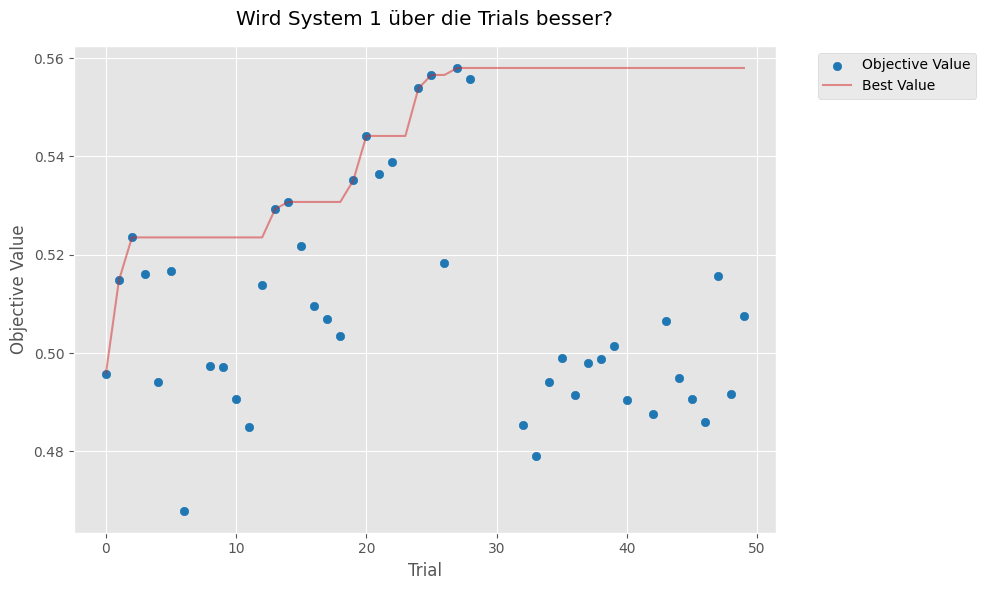

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_10104\4174249492.py:20: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = plot_param_importances(study)


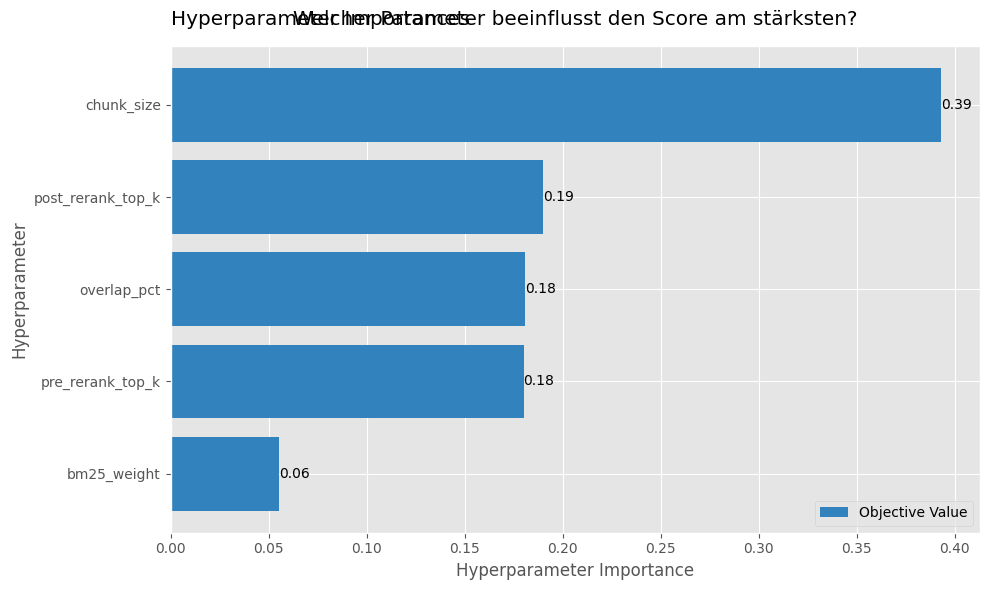

C:\Users\Nutzer\AppData\Local\Temp\ipykernel_10104\4174249492.py:27: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig3 = plot_parallel_coordinate(study)


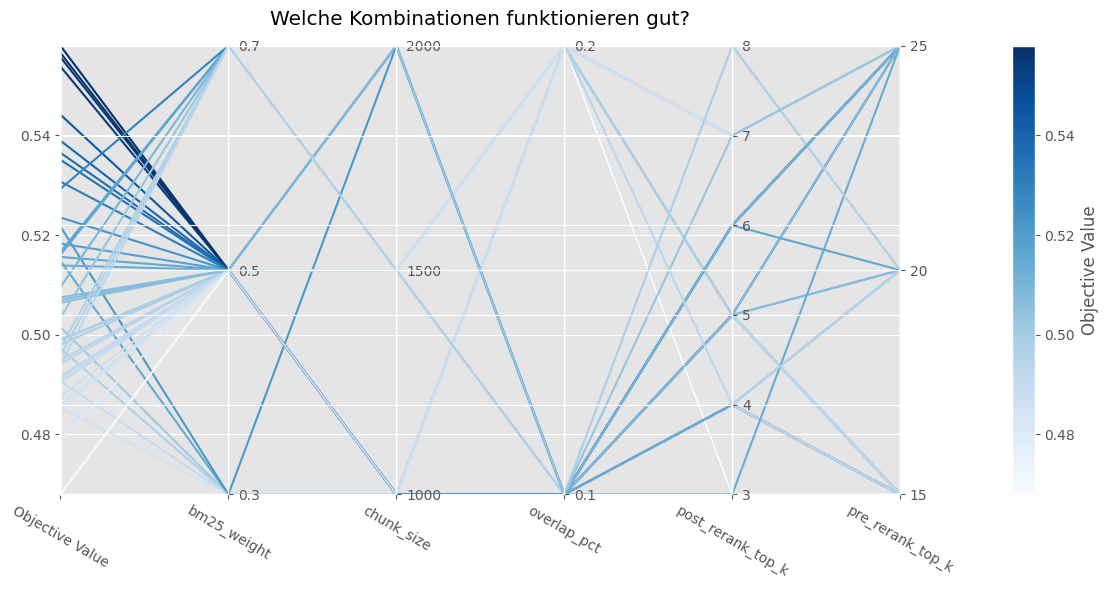

In [9]:
## 5. Visualisierung (Robust mit Matplotlib)
import optuna
from optuna.visualization.matplotlib import plot_optimization_history
from optuna.visualization.matplotlib import plot_param_importances
from optuna.visualization.matplotlib import plot_parallel_coordinate
import matplotlib.pyplot as plt

# Wichtig für sauberes Layout in Notebooks
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Optimization History (Konvergiert der Score?)
fig1 = plot_optimization_history(study)
if fig1.figure._suptitle: fig1.figure.suptitle("") # Verhindert Overlap mit evtl. Figure-Titeln
fig1.set_title("Wird System 1 über die Trials besser?", pad=15)
fig1.figure.tight_layout()
plt.show()

# Parameter Importance (Was ist am wichtigsten?)
fig2 = plot_param_importances(study)
if fig2.figure._suptitle: fig2.figure.suptitle("")
fig2.set_title("Welcher Parameter beeinflusst den Score am stärksten?", pad=15)
fig2.figure.tight_layout()
plt.show()

# Parameter Relationships
fig3 = plot_parallel_coordinate(study)
if fig3.figure._suptitle: fig3.figure.suptitle("")
fig3.set_title("Welche Kombinationen funktionieren gut?", pad=15)
fig3.figure.set_size_inches(12, 6) 
fig3.figure.tight_layout()
plt.show()

## 6. Best Config exportieren

In [10]:
# Export best configuration
config_path = save_best_config(study, output_path=BEST_CONFIG_PATH)

print(f"\n✅ Best config saved to: {config_path}")
print(f"\nBest parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest composite score: {study.best_value:.4f}")

2026-03-24 12:06:33 [INFO] src.systems.rag_monolith.ablation.results_analyzer: Best config saved to c:\Users\Nutzer\Desktop\Uni\Master\Masterarbeit\agentic-financial-report-analysis\configs\best_config.yaml



✅ Best config saved to: c:\Users\Nutzer\Desktop\Uni\Master\Masterarbeit\agentic-financial-report-analysis\configs\best_config.yaml

Best parameters:
  chunk_size: 1000
  overlap_pct: 0.1
  bm25_weight: 0.5
  pre_rerank_top_k: 15
  post_rerank_top_k: 4

Best composite score: 0.5580
